In [401]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Path to dataset files: /kaggle/input/brazilian-ecommerce


In [585]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [402]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
print(os.listdir("/kaggle/input/brazilian-ecommerce"))



['olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv', 'olist_products_dataset.csv', 'olist_geolocation_dataset.csv', 'product_category_name_translation.csv', 'olist_orders_dataset.csv', 'olist_order_payments_dataset.csv']


In [403]:
orders = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv")
customers = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_customers_dataset.csv")
products = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv")
payments = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv")
order_items = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv")
reviews = pd.read_csv("/kaggle/input/brazilian-ecommerce/olist_order_reviews_dataset.csv")

**Order Table**

---



In [404]:
orders.shape


(99441, 8)

In [405]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [406]:
orders.shape

(99441, 8)

In [407]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [408]:
orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [409]:

orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [410]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [411]:
orders.duplicated().sum()

np.int64(0)

In [412]:
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [413]:
orders['order_id'].nunique()

99441

In [414]:
orders['customer_id'].nunique()

99441

In [415]:
orders.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [416]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

In [417]:
orders['order_purchase_timestamp'].min()

Timestamp('2016-09-04 21:15:19')

In [418]:
orders['order_purchase_timestamp'].max()

Timestamp('2018-10-17 17:30:18')

In [419]:
invalid_approval = orders[
    orders['order_approved_at']
    < orders['order_purchase_timestamp']
]

invalid_approval.shape

(0, 8)

In [420]:
invalid_delivery = orders[
    orders['order_delivered_customer_date']
    < orders['order_purchase_timestamp']
]

invalid_delivery.shape

(0, 8)

In [421]:
orders['purchase_year'] = (
    orders['order_purchase_timestamp'].dt.year
)

In [422]:
orders['purchase_month'] = (
    orders['order_purchase_timestamp'].dt.month
)

In [423]:
orders['purchase_day'] = (
    orders['order_purchase_timestamp'].dt.day
)

In [424]:
orders['purchase_hour'] = (
    orders['order_purchase_timestamp'].dt.hour
)

In [425]:
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,19
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,21


In [426]:
orders['order_status'].value_counts(normalize=True) * 100

,proportion
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


In [427]:
monthly_orders = orders.groupby(
    ['purchase_year', 'purchase_month']
).size().reset_index(name='total_orders')

monthly_orders.head()

,purchase_year,purchase_month,total_orders
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780


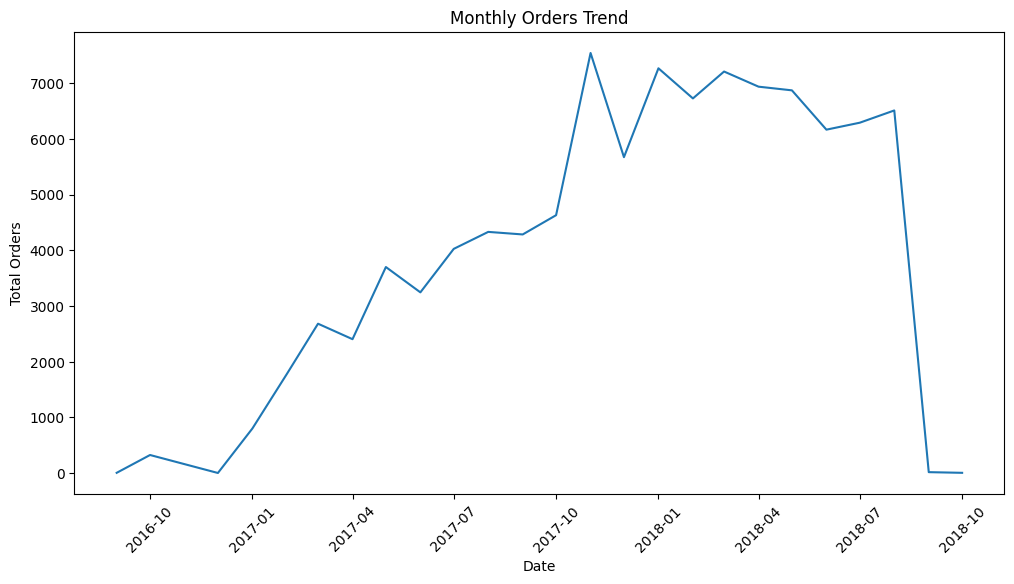

In [428]:
monthly_orders['date'] = pd.to_datetime(
    monthly_orders['purchase_year'].astype(str) + '-' +
    monthly_orders['purchase_month'].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_orders['date'],
    monthly_orders['total_orders']
)

plt.title('Monthly Orders Trend')
plt.xlabel('Date')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)

plt.show()

In [429]:
hourly_orders = orders.groupby('purchase_hour')['order_id'].count().reset_index()

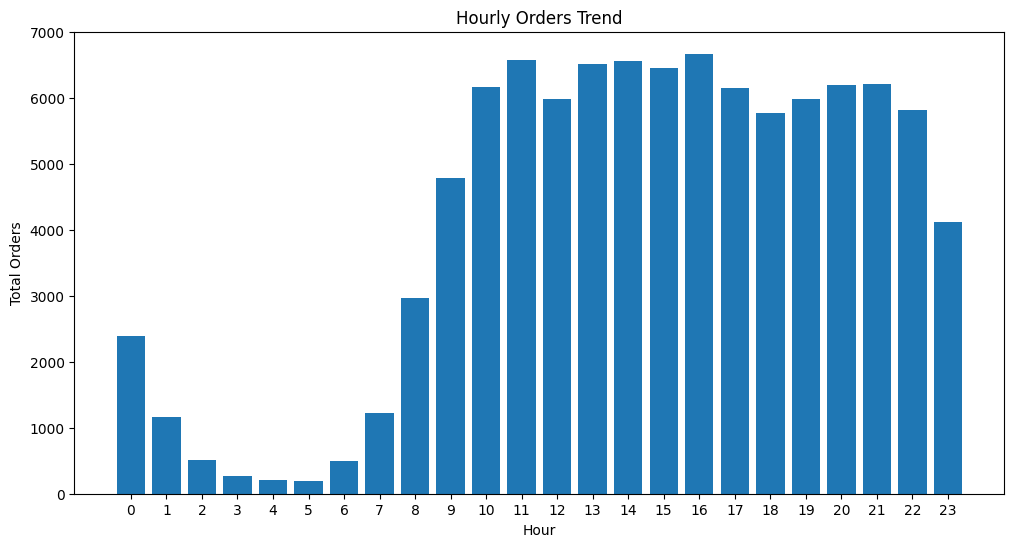

In [430]:
hourly_orders.columns = ['purchase_hour', 'total_orders']

plt.figure(figsize=(12,6))

plt.bar(
    hourly_orders['purchase_hour'],
    hourly_orders['total_orders']
)

plt.title('Hourly Orders Trend')
plt.xlabel('Hour')
plt.ylabel('Total Orders')

plt.xticks(hourly_orders['purchase_hour'])

plt.show()

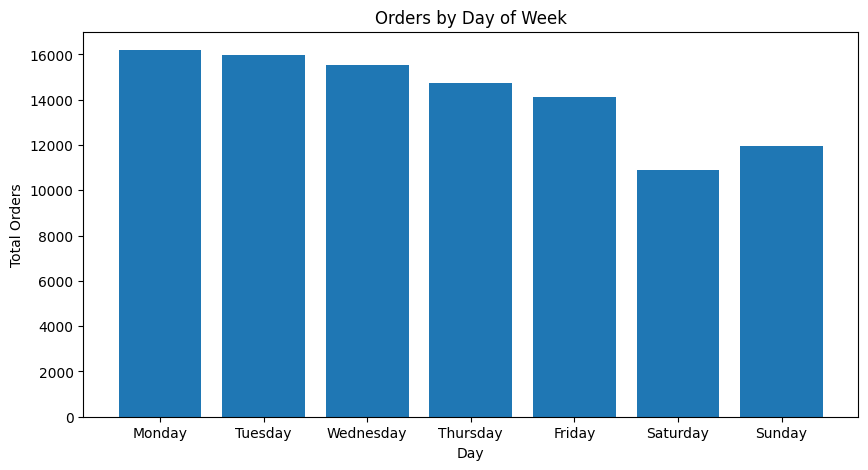

In [431]:
orders['purchase_day_name'] = orders[
    'order_purchase_timestamp'
].dt.day_name()

day_orders = orders.groupby(
    'purchase_day_name'
)['order_id'].count().reset_index()

day_orders.columns = ['day', 'total_orders']

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

day_orders['day'] = pd.Categorical(
    day_orders['day'],
    categories=day_order,
    ordered=True
)

day_orders = day_orders.sort_values('day')

plt.figure(figsize=(10,5))

plt.bar(day_orders['day'], day_orders['total_orders'])

plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Orders')

plt.show()

In [432]:
delivered_orders = orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_delivered_customer_date'].notna())
].copy()

delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
).dt.days

In [433]:
delivered_orders['delivery_days'].describe()

,delivery_days
count,96470.000000
mean,12.093604
std,9.551380
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


In [434]:
delivered_orders['is_late'] = (
    delivered_orders['order_delivered_customer_date']
    >
    delivered_orders['order_estimated_delivery_date']
)

In [435]:
delivered_orders['is_late'].value_counts()

,count
is_late,
False,88644
True,7826


In [436]:
late_percent = (
    delivered_orders['is_late'].mean()
) * 100

print(late_percent)

8.112366538820359


In [437]:
status_percent = (
    orders['order_status']
    .value_counts(normalize=True) * 100
)

print(status_percent)

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64


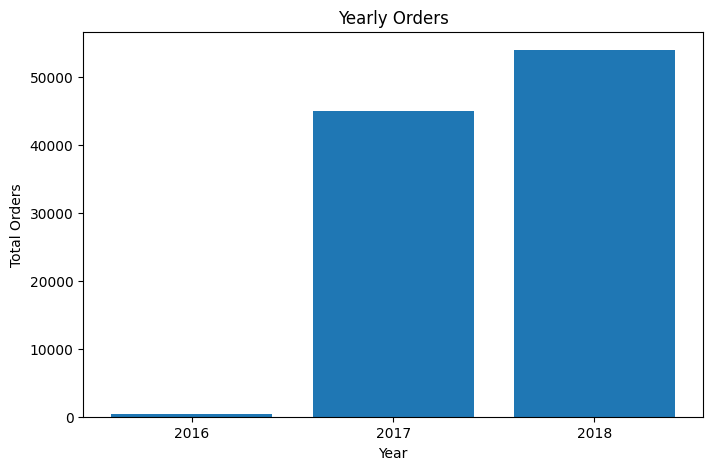

In [438]:
yearly_orders = orders.groupby(
    'purchase_year'
)['order_id'].count().reset_index()

yearly_orders.columns = [
    'year',
    'total_orders'
]

plt.figure(figsize=(8,5))

plt.bar(
    yearly_orders['year'].astype(str),
    yearly_orders['total_orders']
)

plt.title('Yearly Orders')
plt.xlabel('Year')
plt.ylabel('Total Orders')

plt.show()

Customer Table

---



In [439]:
customers.shape

(99441, 5)

In [440]:
customers.columns.to_list()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [441]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [442]:
customers.isna().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [443]:
customers.duplicated().sum()

np.int64(0)

In [444]:
customers['customer_id'].nunique()

99441

In [445]:
customers['customer_unique_id'].nunique()

96096

In [446]:
customer_multi_orders = customers.groupby('customer_unique_id')['customer_id'].count()

In [447]:
print(customer_multi_orders)

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: customer_id, Length: 96096, dtype: int64


In [448]:
customer_multi_orders = customer_multi_orders[customer_multi_orders > 1]
print(customer_multi_orders)

customer_unique_id
00172711b30d52eea8b313a7f2cced02    2
004288347e5e88a27ded2bb23747066c    2
004b45ec5c64187465168251cd1c9c2f    2
0058f300f57d7b93c477a131a59b36c3    2
00a39521eb40f7012db50455bf083460    2
                                   ..
ff36be26206fffe1eb37afd54c70e18b    3
ff44401d0d8f5b9c54a47374eb48c1b8    2
ff8892f7c26aa0446da53d01b18df463    2
ff922bdd6bafcdf99cb90d7f39cea5b3    3
ffe254cc039740e17dd15a5305035928    2
Name: customer_id, Length: 2997, dtype: int64


In [449]:
customers_multi_orders_count = customer_multi_orders.count()
print(customers_multi_orders_count)

2997


In [450]:
# Check unique states
customers['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

In [451]:
# Number of unique states
customers['customer_state'].nunique()

27

In [452]:
# Check sample unique city names
customers['customer_city'].unique()[:50]

array(['franca', 'sao bernardo do campo', 'sao paulo', 'mogi das cruzes',
       'campinas', 'jaragua do sul', 'timoteo', 'curitiba',
       'belo horizonte', 'montes claros', 'rio de janeiro',
       'lencois paulista', 'caxias do sul', 'piracicaba', 'guarulhos',
       'pacaja', 'florianopolis', 'aparecida de goiania', 'santo andre',
       'goiania', 'cachoeiro de itapemirim', 'sao jose dos campos',
       'sao roque', 'camacari', 'resende', 'sumare', 'novo hamburgo',
       'sao luis', 'sao jose', 'santa barbara', 'ribeirao preto',
       'ituiutaba', 'taquarituba', 'sao jose dos pinhais', 'barrinha',
       'parati', 'dourados', 'trindade', 'cascavel', 'fortaleza',
       'brasilia', 'pelotas', 'porto alegre', 'salto', 'jundiai',
       'cacapava', 'sao vicente', 'uberlandia', 'botelhos', 'sao goncalo'],
      dtype=object)

In [453]:
# Number of unique cities
customers['customer_city'].nunique()

4119

In [454]:
# Check if city names contain uppercase letters
customers[
    customers['customer_city'] !=
    customers['customer_city'].str.lower()
]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [455]:
# Check for leading/trailing spaces
customers[
    customers['customer_city'] !=
    customers['customer_city'].str.strip()
]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state


In [456]:
# Check frequency of city names
customers['customer_city'].value_counts().head(20)

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


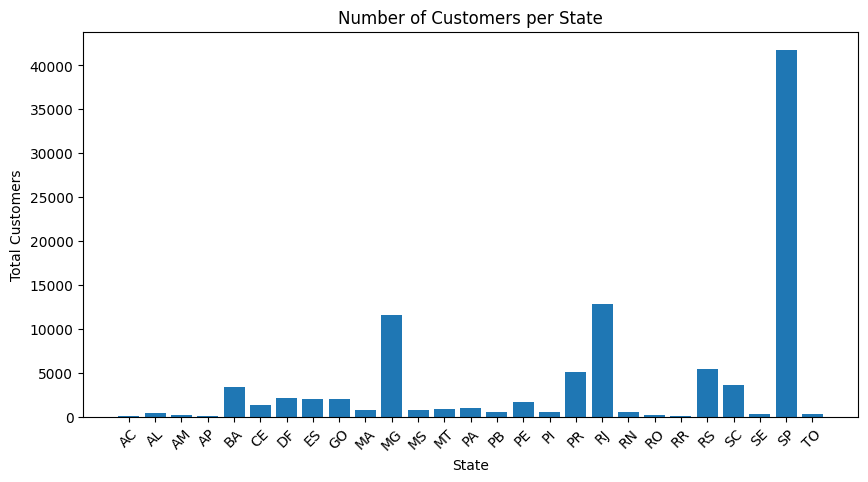

In [457]:
customers_per_state = customers.groupby('customer_state')['customer_id'].count().reset_index()
customers_per_state.columns = ['state', 'total_customers']
plt.figure(figsize=(10,5))
plt.bar(
    customers_per_state['state'],
    customers_per_state['total_customers']
)
plt.title('Number of Customers per State')
plt.xlabel('State')
plt.ylabel('Total Customers')
plt.xticks(rotation=45)
plt.show()

In [458]:
customer_per_city = customers.groupby(
    'customer_city'
)['customer_id'].count().reset_index()

customer_per_city.columns = [
    'city',
    'total_customers'
]

customer_per_city = customer_per_city.sort_values(
    by='total_customers',
    ascending=False
)

top_city = customer_per_city.head(10)

print(top_city)

                       city  total_customers
3597              sao paulo            15540
3155         rio de janeiro             6882
453          belo horizonte             2773
558                brasilia             2131
1143               curitiba             1521
707                campinas             1444
2964           porto alegre             1379
3247               salvador             1245
1529              guarulhos             1189
3428  sao bernardo do campo              938


In [459]:
(customers.groupby('customer_state')['customer_id'].count() / customers['customer_id'].count() * 100).sort_values(ascending=False)

,customer_id
customer_state,
SP,41.980672
RJ,12.924247
MG,11.700405
RS,5.496727
PR,5.073360
SC,3.657445
BA,3.399000
DF,2.152030
ES,2.044428


**Product Table**

---



In [460]:
products.shape

(32951, 9)

In [461]:
products.columns.to_list()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [462]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [463]:
products.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [464]:
(products.isna().sum() / len(products)) * 100

,0
product_id,0.000000
product_category_name,1.851234
product_name_lenght,1.851234
product_description_lenght,1.851234
product_photos_qty,1.851234
product_weight_g,0.006070
product_length_cm,0.006070
product_height_cm,0.006070
product_width_cm,0.006070


In [465]:
products_cleaned = products.dropna(
    subset=['product_category_name',
            'product_name_lenght',
            'product_description_lenght',
            'product_photos_qty',
            'product_weight_g',
            'product_length_cm',
            'product_height_cm',
            'product_width_cm'
            ]
)

In [475]:
products_cleaned.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [466]:
products = products_cleaned.copy()

In [584]:
products[
    products['product_category_name'].isna()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [468]:
products['product_category_name'].nunique()

73

In [469]:
top_categories = products.groupby(
    'product_category_name'
)['product_id'].count().reset_index()

top_categories.columns = [
    'category',
    'total_products'
]

top_categories = top_categories.sort_values(
    by='total_products',
    ascending=False
)

top_categories.head(10)

,category,total_products
13,cama_mesa_banho,3029
32,esporte_lazer,2867
54,moveis_decoracao,2657
11,beleza_saude,2444
72,utilidades_domesticas,2335
8,automotivo,1900
44,informatica_acessorios,1639
12,brinquedos,1411
66,relogios_presentes,1329
70,telefonia,1134


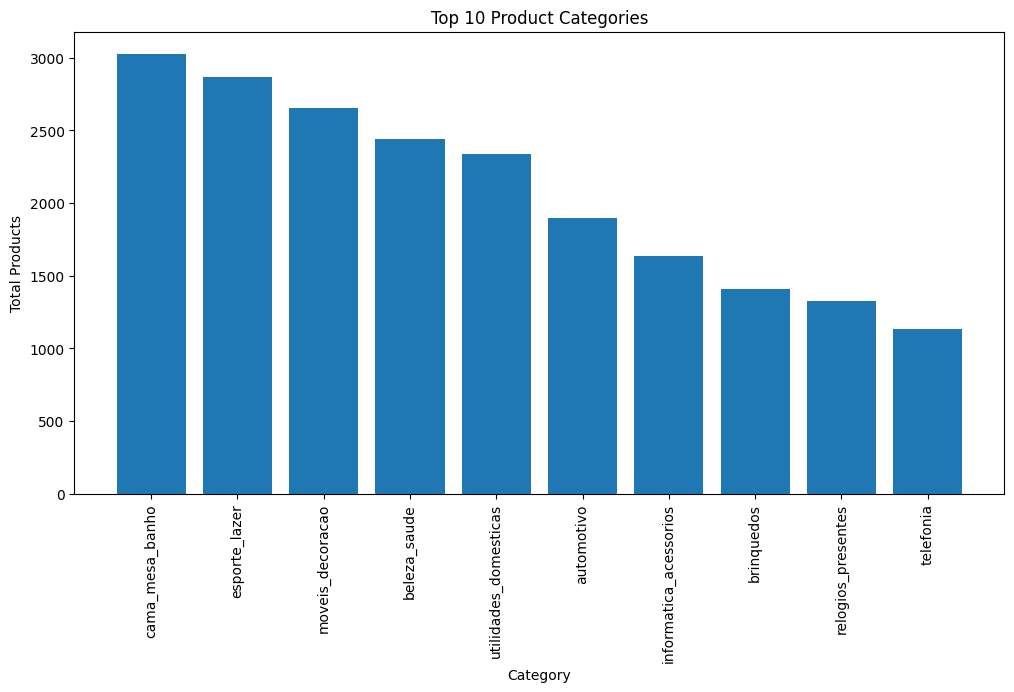

In [470]:
plt.figure(figsize=(12,6))

plt.bar(
    top_categories['category'].head(10),
    top_categories['total_products'].head(10)
)

plt.title('Top 10 Product Categories')
plt.xlabel('Category')
plt.ylabel('Total Products')

plt.xticks(rotation=90)

plt.show()

In [471]:
(products['product_weight_g'] == 0).sum()

np.int64(4)

In [472]:
products[
    products['product_weight_g'] == 0
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
9769,81781c0fed9fe1ad6e8c81fca1e1cb08,cama_mesa_banho,51.0,529.0,1.0,0.0,30.0,25.0,30.0
13683,8038040ee2a71048d4bdbbdc985b69ab,cama_mesa_banho,48.0,528.0,1.0,0.0,30.0,25.0,30.0
14997,36ba42dd187055e1fbe943b2d11430ca,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0
32079,e673e90efa65a5409ff4196c038bb5af,cama_mesa_banho,53.0,528.0,1.0,0.0,30.0,25.0,30.0


In [473]:
products.sort_values(
    by='product_weight_g',
    ascending=False
).head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
25166,26644690fde745fc4654719c3904e1db,cama_mesa_banho,59.0,534.0,1.0,40425.0,13.0,65.0,28.0
7535,9dfef86fb34051388a7263a31642386c,beleza_saude,57.0,543.0,1.0,30000.0,55.0,75.0,61.0
7422,bbc5419bc92d76e27795c9ec2c233c64,beleza_saude,51.0,423.0,1.0,30000.0,55.0,75.0,61.0
17914,616c497aa9cc2d4ce93eb380cf5cc121,cama_mesa_banho,54.0,360.0,1.0,30000.0,45.0,15.0,35.0
17993,f6a84928571f68635beb0f5c9333c6f3,esporte_lazer,60.0,1247.0,6.0,30000.0,86.0,66.0,36.0
17765,81258a06e30546c898c31a062ae3da08,cama_mesa_banho,57.0,258.0,2.0,30000.0,43.0,19.0,35.0
11327,8d4e92265a16e69a1e1d76e67e46d72f,instrumentos_musicais,45.0,422.0,5.0,30000.0,80.0,75.0,36.0
5675,aed75ad669fbebd5a385ac7cc2ae7573,beleza_saude,42.0,427.0,1.0,30000.0,50.0,75.0,56.0
30340,660422061e06da17ca6101e9d6b7aae8,esporte_lazer,35.0,1214.0,4.0,30000.0,40.0,97.0,40.0
28145,0e9dfb804bafa3d68ef3ee7a621abfb2,moveis_sala,17.0,531.0,3.0,30000.0,68.0,55.0,77.0


In [474]:
products[
    products['product_description_lenght'] < 20
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
3601,dd5a5e7b2b76089d6415070e8d6d5456,utilidades_domesticas,52.0,4.0,1.0,1450.0,27.0,29.0,26.0
8114,6d066313ce43d3ed9fdfa17b4fb69baa,bebes,31.0,4.0,2.0,855.0,36.0,23.0,28.0
10402,67f95d5d22a25ae3c8c0651319c7d355,utilidades_domesticas,55.0,4.0,2.0,681.0,39.0,7.0,28.0
21124,fbf7215badcb7ebd5b322b71a0733fb8,utilidades_domesticas,55.0,4.0,2.0,5534.0,73.0,16.0,45.0
21351,73f0291fe089e68d9d01418708e3f192,fashion_bolsas_e_acessorios,51.0,15.0,1.0,250.0,16.0,2.0,11.0
23474,519f998a3890d844a5f27a99c69d2c6a,utilidades_domesticas,43.0,4.0,1.0,1045.0,39.0,16.0,38.0
32255,0d17caa71904fab71aaa37e8a370dc8d,informatica_acessorios,49.0,8.0,1.0,825.0,30.0,16.0,16.0


In [476]:
products.duplicated().sum()

np.int64(0)

In [477]:
products['product_id'].nunique()

32340

In [478]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
mean,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [479]:
# Check sample category names
products['product_category_name'].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio',
       'moveis_sala', 'sinalizacao_e_seguranca', 'climatizacao',
       'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa',
       '

In [480]:
# Number of unique product categories
products['product_category_name'].nunique()

73

In [481]:
# Check if category names contain uppercase letters
products[
    products['product_category_name'] !=
    products['product_category_name'].str.lower()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [482]:
# Check for leading/trailing spaces
products[
    products['product_category_name'] !=
    products['product_category_name'].str.strip()
]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [483]:
# Frequency of product categories
products['product_category_name'].value_counts().head(20)

,count
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


**Order Items Table**

---



In [484]:
order_items.shape

(112650, 7)

In [485]:
order_items.columns.to_list()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [486]:
order_items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,object
price,float64
freight_value,float64


In [487]:
order_items.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [488]:
order_items.duplicated().sum()

np.int64(0)

In [489]:
order_items['order_item_id'].is_unique

False

In [490]:
order_items['order_id'].is_unique

False

so order_id has some duplicate but no duplicates rows that mean one order_id has multiple products that purchased by customer

In [491]:
order_items[['order_id', 'order_item_id']].duplicated().sum()

np.int64(0)

i just find out that order_item_id shows duplicates but they are not bad duplicates because it represent the id of different items in different orders

In [492]:
order_items[['price', 'freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [493]:
order_items[order_items['price'] < 0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [494]:
order_items[order_items['freight_value'] < 0]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [495]:
(order_items['price'] == 0).sum()

np.int64(0)

In [496]:
(order_items['freight_value'] == 0).sum()

np.int64(383)

In [497]:
order_items.sort_values(by='price', ascending=False).head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34


In [498]:
order_items['price'].quantile([0.95, 0.99])

,price
0.95,349.9
0.99,890.0


In [499]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

In [500]:
order_items['shipping_limit_date'].dtype

dtype('<M8[ns]')

In [501]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Feature **Engineering**

---



In [502]:
order_items['total_item_value'] = order_items['price']+order_items['freight_value']


In [503]:
order_items['freight_percentage'] = (order_items['freight_value'] / order_items['price'])*100

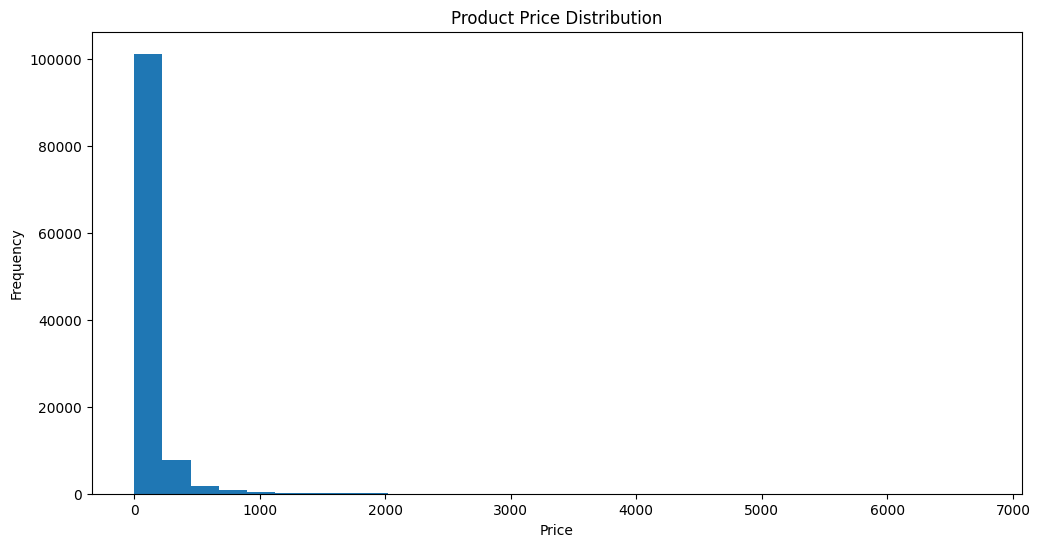

In [504]:
plt.figure(figsize=(12,6))

plt.hist(order_items['price'], bins=30)

plt.title('Product Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

In [505]:
most_exp_products = order_items.sort_values(
    by='price',
    ascending=False
).head(1)

print(most_exp_products)

                              order_id  order_item_id  \
3556  0812eb902a67711a1cb742b3cdaa65ae              1   

                            product_id                         seller_id  \
3556  489ae2aa008f021502940f251d4cce7f  e3b4998c7a498169dc7bce44e6bb6277   

     shipping_limit_date   price  freight_value  total_item_value  \
3556 2017-02-16 20:37:36  6735.0         194.31           6929.31   

      freight_percentage  
3556            2.885078  


In [506]:
most_cheap_products = order_items.sort_values(
    by='price',
    ascending=True
).head(1)

print(most_cheap_products)

                               order_id  order_item_id  \
27652  3ee6513ae7ea23bdfab5b9ab60bffcb5              1   

                             product_id                         seller_id  \
27652  8a3254bee785a526d548a81a9bc3c9be  96804ea39d96eb908e7c3afdb671bb9e   

      shipping_limit_date  price  freight_value  total_item_value  \
27652 2018-05-04 03:55:26   0.85          18.23             19.08   

       freight_percentage  
27652         2144.705882  


In [507]:
avg_price_per_product = order_items['price'].mean()

print(avg_price_per_product)

120.65373901464716


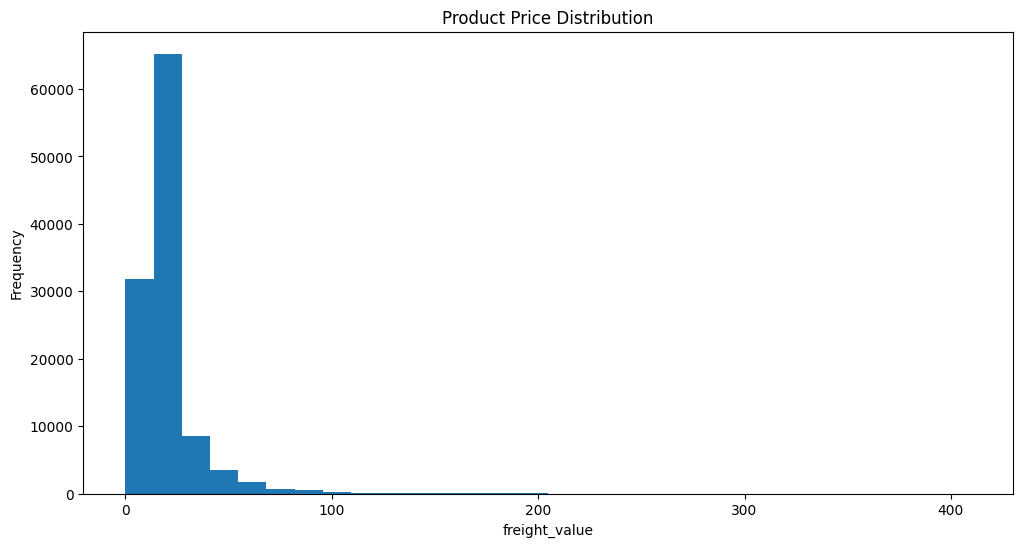

In [508]:
plt.figure(figsize=(12,6))

plt.hist(order_items['freight_value'], bins=30)

plt.title('Product Price Distribution')
plt.xlabel('freight_value')
plt.ylabel('Frequency')

plt.show()

In [509]:
avg_freight_cost = order_items['freight_value'].mean()

print(avg_freight_cost)

19.990319928983578


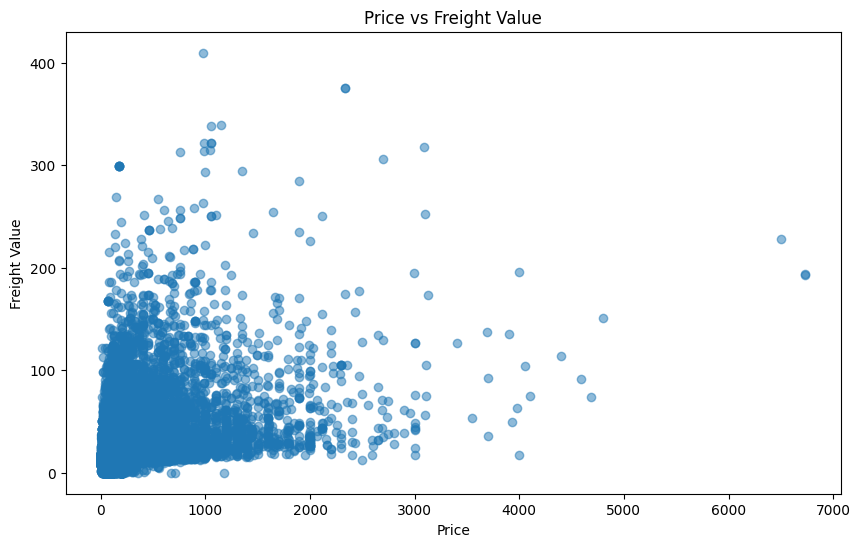

In [510]:
plt.figure(figsize=(10,6))

plt.scatter(
    order_items['price'],
    order_items['freight_value'],
    alpha=0.5
)

plt.title('Price vs Freight Value')
plt.xlabel('Price')
plt.ylabel('Freight Value')

plt.show()

In [511]:
order_items[['price', 'freight_value']].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


In [512]:
items_count = order_items.groupby('order_id')['order_item_id'].count().reset_index()

items_count.columns = ['order_id', 'items_count']

items_count.head(10)

,order_id,items_count
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1
5,00048cc3ae777c65dbb7d2a0634bc1ea,1
6,00054e8431b9d7675808bcb819fb4a32,1
7,000576fe39319847cbb9d288c5617fa6,1
8,0005a1a1728c9d785b8e2b08b904576c,1
9,0005f50442cb953dcd1d21e1fb923495,1


In [513]:
items_count.sort_values(by='items_count', ascending=False).head(10)

,order_id,items_count
50137,8272b63d03f5f79c56e9e4120aec44ef,21
10459,1b15974a0141d54e36626dca3fdc731a,20
65715,ab14fdcfbe524636d65ee38360e22ce8,20
60941,9ef13efd6949e4573a18964dd1bbe7f5,15
25583,428a2f660dc84138d969ccd69a0ab6d5,15
59688,9bdc4d4c71aa1de4606060929dee888c,14
44594,73c8ab38f07dc94389065f7eba4f297a,14
21484,37ee401157a3a0b28c9c6d0ed8c3b24b,13
16854,2c2a19b5703863c908512d135aa6accc,12
67424,af822dacd6f5cff7376413c03a388bb7,12


In [514]:
items_count.sort_values(by='items_count', ascending=False).head(1)

,order_id,items_count
50137,8272b63d03f5f79c56e9e4120aec44ef,21


In [515]:
order_items['seller_id'].nunique()

3095

In [516]:
order_items['seller_id'].value_counts().head(10)

,count
seller_id,
6560211a19b47992c3666cc44a7e94c0,2033
4a3ca9315b744ce9f8e9374361493884,1987
1f50f920176fa81dab994f9023523100,1931
cc419e0650a3c5ba77189a1882b7556a,1775
da8622b14eb17ae2831f4ac5b9dab84a,1551
955fee9216a65b617aa5c0531780ce60,1499
1025f0e2d44d7041d6cf58b6550e0bfa,1428
7c67e1448b00f6e969d365cea6b010ab,1364
ea8482cd71df3c1969d7b9473ff13abc,1203


Payments **Table**

---



In [517]:
payments.shape

(103886, 5)

In [518]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [519]:
payments.columns.to_list()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [520]:
payments.dtypes

,0
order_id,object
payment_sequential,int64
payment_type,object
payment_installments,int64
payment_value,float64


In [521]:
payments.isna().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [522]:
payments.duplicated().sum()

np.int64(0)

In [523]:
payments['order_id'].is_unique

False

In [524]:
payments['order_id'].nunique()

99440

In [525]:
payments[['payment_installments', 'payment_value']].describe()

,payment_installments,payment_value
count,103886.000000,103886.000000
mean,2.853349,154.100380
std,2.687051,217.494064
min,0.000000,0.000000
25%,1.000000,56.790000
50%,1.000000,100.000000
75%,4.000000,171.837500
max,24.000000,13664.080000


In [526]:
payments[payments['payment_installments'] < 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [527]:
payments[payments['payment_value'] < 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value


In [528]:
(payments['payment_installments'] == 0).sum()

np.int64(2)

In [529]:
(payments['payment_value'] == 0).sum()

np.int64(9)

In [530]:
payments[payments['payment_installments'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
46982,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
79014,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94


In [531]:
payments[payments['payment_value'] == 0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [532]:
payments['payment_installments'].value_counts().sort_index()

,count
payment_installments,
0,2
1,52546
2,12413
3,10461
4,7098
5,5239
6,3920
7,1626
8,4268


In [533]:
payments.sort_values(
    by='payment_value',
    ascending=False
).head(10)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
52107,03caa2c082116e1d31e67e9ae3700499,1,credit_card,1,13664.08
34370,736e1922ae60d0d6a89247b851902527,1,boleto,1,7274.88
41419,0812eb902a67711a1cb742b3cdaa65ae,1,credit_card,8,6929.31
49581,fefacc66af859508bf1a7934eab1e97f,1,boleto,1,6922.21
85539,f5136e38d1a14a4dbd87dff67da82701,1,boleto,1,6726.66
62409,2cc9089445046817a7539d90805e6e5a,1,boleto,1,6081.54
43232,a96610ab360d42a2e5335a3998b4718a,1,credit_card,10,4950.34
70320,b4c4b76c642808cbe472a32b86cddc95,1,credit_card,5,4809.44
6440,199af31afc78c699f0dbf71fb178d4d4,1,credit_card,8,4764.34
67546,8dbc85d1447242f3b127dda390d56e19,1,credit_card,8,4681.78


In [534]:
payments['payment_value'].quantile([0.95, 0.99])

,payment_value
0.95,437.6350
0.99,1039.9165


In [535]:
payments['payment_type'].value_counts()

,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [536]:
Q1 = order_items['price'].quantile(0.25)
Q3 = order_items['price'].quantile(0.75)

IQR = Q3 - Q1

In [537]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [538]:
outliers = order_items[
    (order_items['price'] < lower_bound) |
    (order_items['price'] > upper_bound)
]

outliers

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_item_value,freight_percentage
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,880.75,8.734568
16,0009c9a17f916a706d71784483a5d643,1,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,2018-05-02 09:31:53,639.00,11.34,650.34,1.774648
26,0011d82c4b53e22e84023405fb467e57,1,c389f712c4b4510bc997cee93e8b1a28,bfd27a966d91cfaafdb25d076585f0da,2018-01-29 21:51:25,289.00,26.33,315.33,9.110727
30,00137e170939bba5a3134e2386413108,1,672e757f331900b9deea127a2a7b79fd,e59aa562b9f8076dd550fcddf0e73491,2017-11-30 06:30:55,397.00,24.65,421.65,6.209068
39,0017afd5076e074a48f1f1a4c7bac9c5,1,fe59a1e006df3ac42bf0ceb876d70969,25c5c91f63607446a97b143d2d535d31,2017-04-24 22:25:19,809.10,44.29,853.39,5.473983
...,...,...,...,...,...,...,...,...,...
112586,ffdc5e3279114c523a09296f8fd28331,1,5e70a4508abd5d19bfe7f110785294c8,328acb143b4a73aad6bee8e734f5d20d,2017-02-14 14:49:23,299.99,17.80,317.79,5.933531
112592,ffde92ba447b33a47d1c04d203f10f41,1,a97cd00f5c1dbfbc7f0f4b6c1032253e,b347677812ea483b0f528eaf8cbc09b7,2017-11-30 14:13:18,278.00,26.70,304.70,9.604317
112632,fff7c4452f050315db1b3f24d9df5fcd,1,dd469c03ad67e201bc2179ef077dcd48,7e93a43ef30c4f03f38b393420bc753a,2017-06-07 17:05:23,736.00,20.91,756.91,2.841033
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,343.40,14.470482


In [539]:
outliers.shape[0]

8427

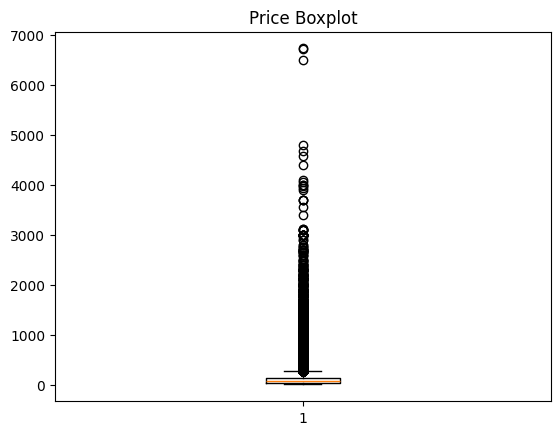

In [540]:
import matplotlib.pyplot as plt

plt.boxplot(order_items['price'])
plt.title('Price Boxplot')
plt.show()

In [541]:
outlier_count = 8427

(outlier_count / len(order_items)) * 100

7.480692410119841

In [542]:
payments['payment_category'] = payments['payment_installments'].apply(
    lambda x: 'Single Payment' if x == 1 else 'Installment Payment'
)

In [543]:
payments['payment_category'].value_counts()

,count
payment_category,
Single Payment,52546
Installment Payment,51340


Feature Engineering

In [544]:
payments['is_installment'] = payments['payment_category'].apply(
    lambda x: 1 if x == 'Installment Payment' else 0
)

In [545]:
payments.head(5)

,order_id,payment_sequential,payment_type,payment_installments,payment_value,payment_category,is_installment
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,Installment Payment,1
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,Single Payment,0
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,Single Payment,0
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,Installment Payment,1
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,Installment Payment,1


EDA

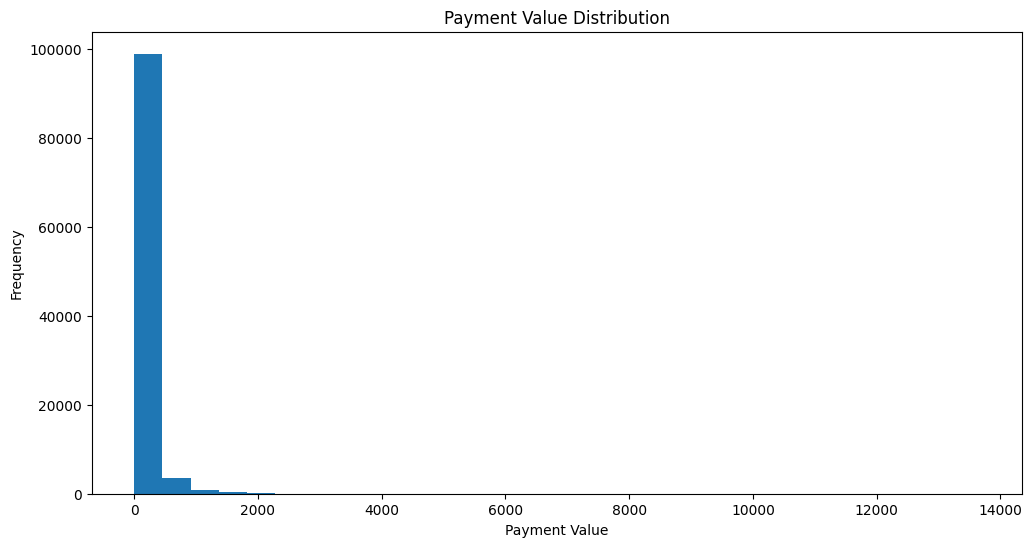

In [546]:
plt.figure(figsize=(12,6))

plt.hist(payments['payment_value'], bins=30)

plt.title('Payment Value Distribution')
plt.xlabel('Payment Value')
plt.ylabel('Frequency')

plt.show()

In [547]:
payments['payment_value'].mean()

np.float64(154.10038041699553)

In [548]:
payments['payment_value'].min()

0.0

In [549]:
payments['payment_value'].max()

13664.08

In [550]:
payments['payment_type'].value_counts().sort_values(ascending =False)


,count
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


In [551]:
payments['payment_type'].value_counts()/len(payments['payment_type'])*100

,count
payment_type,
credit_card,73.922376
boleto,19.043952
voucher,5.558978
debit_card,1.471806
not_defined,0.002888


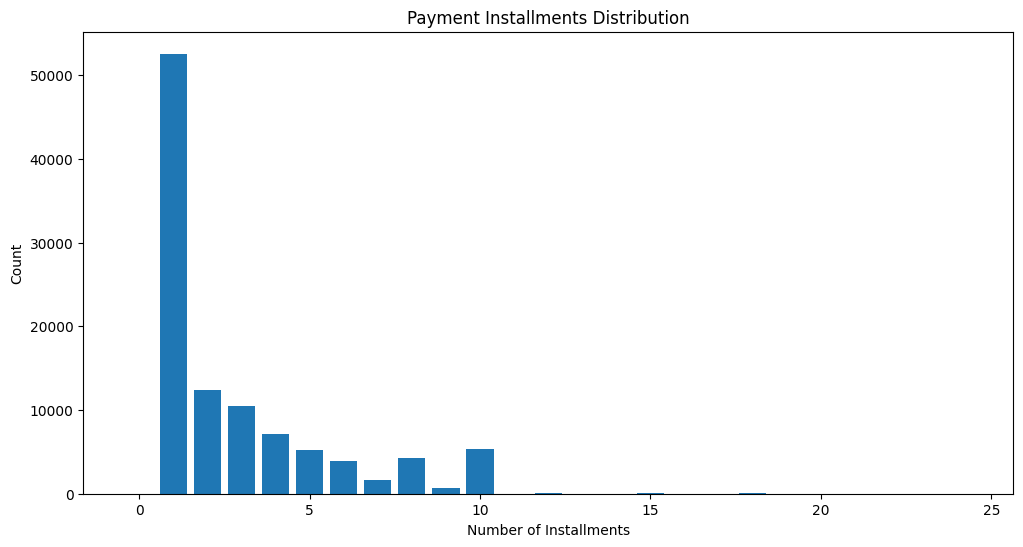

In [552]:
installment_counts = (
    payments['payment_installments']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,6))

plt.bar(
    installment_counts.index,
    installment_counts.values
)

plt.title('Payment Installments Distribution')
plt.xlabel('Number of Installments')
plt.ylabel('Count')

plt.show()

In [553]:
payments['payment_installments'].mean()

np.float64(2.853348863176944)

In [554]:
payments['payment_installments'].max()

24

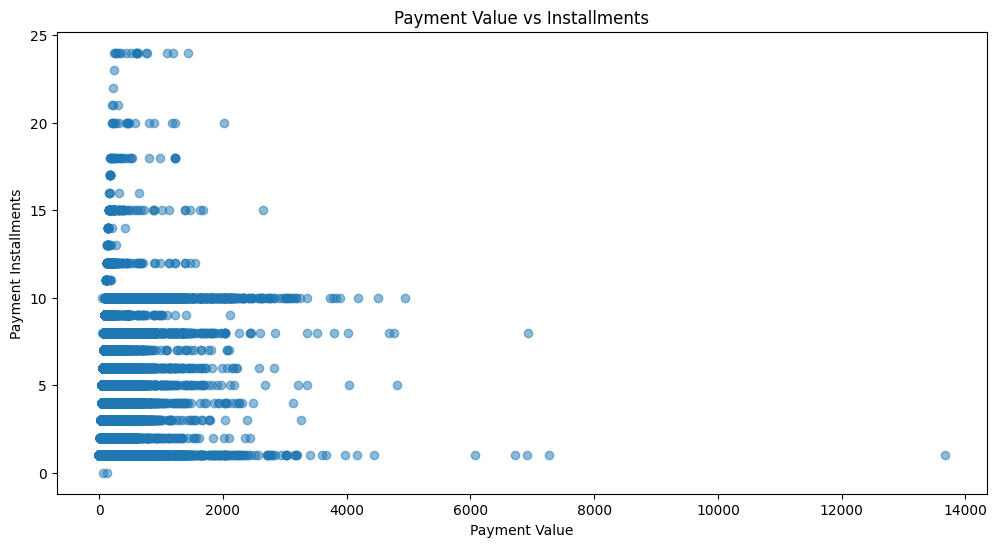

In [555]:
plt.figure(figsize=(12,6))

plt.scatter(
    payments['payment_value'],
    payments['payment_installments'],
    alpha = 0.5
)

plt.title('Payment Value vs Installments')
plt.xlabel('Payment Value')
plt.ylabel('Payment Installments')

plt.show()











**Reviews** **Table**

---



In [556]:
reviews.shape

(99224, 7)

In [557]:
reviews.columns.to_list()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [558]:
reviews.dtypes

,0
review_id,object
order_id,object
review_score,int64
review_comment_title,object
review_comment_message,object
review_creation_date,object
review_answer_timestamp,object


In [559]:
reviews.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [560]:
reviews.duplicated().sum()

np.int64(0)

In [561]:
reviews['review_id'].is_unique

False

In [562]:
reviews['order_id'].is_unique

False

In [563]:
reviews[(reviews['review_score'] < 1) | (reviews['review_score'] > 5 )]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [564]:
reviews['review_score'].value_counts()

,count
review_score,
5,57328
4,19142
1,11424
3,8179
2,3151


In [565]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')

In [566]:
reviews['review_creation_date'].min()

Timestamp('2016-10-02 00:00:00')

In [567]:
reviews['review_creation_date'].max()

Timestamp('2018-08-31 00:00:00')

In [568]:
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')

In [569]:
reviews['review_answer_timestamp'].agg(['min', 'max'])

,review_answer_timestamp
min,2016-10-07 18:32:28
max,2018-10-29 12:27:35


In [570]:
reviews['review_sentiment'] = reviews['review_score'].apply(lambda x: 'Negative' if x <= 2 else 'Neutral' if x == 3 else 'Positive')

In [571]:
reviews['is_positive_review'] = reviews['review_sentiment'].apply(lambda x: 1 if x == 'Positive' else 0)

In [572]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,review_sentiment,is_positive_review
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59,Positive,1
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13,Positive,1
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24,Positive,1
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06,Positive,1
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53,Positive,1


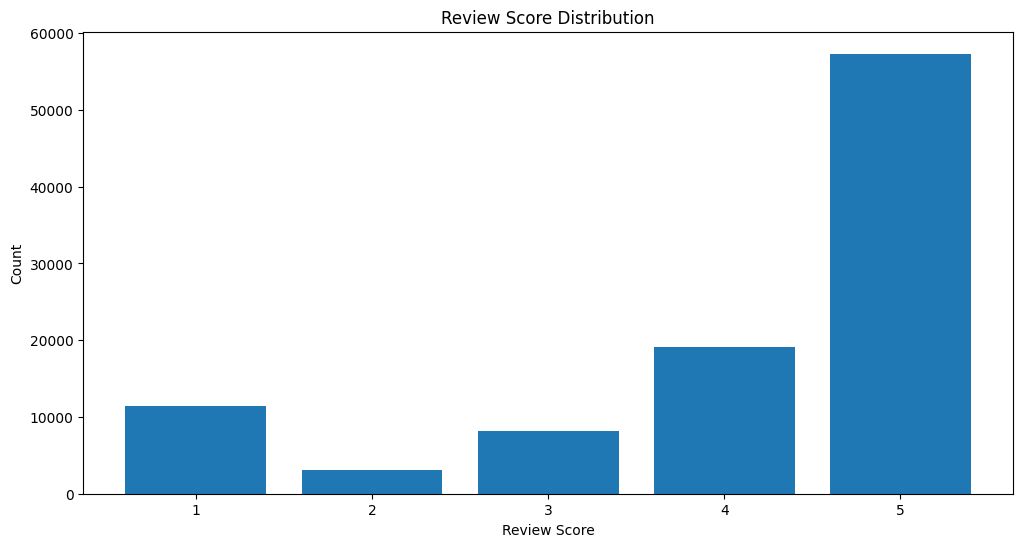

In [573]:
plt.figure(figsize=(12,6))

plt.bar(reviews['review_score'].value_counts().index, reviews['review_score'].value_counts().values)

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')

plt.show()



In [574]:
reviews['review_score'].mean()

np.float64(4.08642062404257)

In [575]:
reviews['review_score'].value_counts().head(1)

,count
review_score,
5,57328


In [576]:
(reviews['review_score'].value_counts()/len(reviews['review_score'])*100).head(1)

,count
review_score,
5,57.776344


In [577]:
(reviews['review_score'].value_counts()/len(reviews['review_score'])*100).sort_values(ascending=True).head(1)

,count
review_score,
2,3.175643


In [578]:
reviews['review_sentiment'].value_counts()

,count
review_sentiment,
Positive,76470
Negative,14575
Neutral,8179


In [579]:
reviews['review_comment_title'].notna().sum()

np.int64(11568)

In [580]:
reviews['review_comment_message'].notna().sum()

np.int64(40977)

In [581]:
reviews['review_comment_message'].notna().sum()/len(reviews['review_comment_message'])*100

np.float64(41.29746835443038)

In [582]:
reviews['review_comment_message'].notna().mean() * 100

np.float64(41.29746835443038)

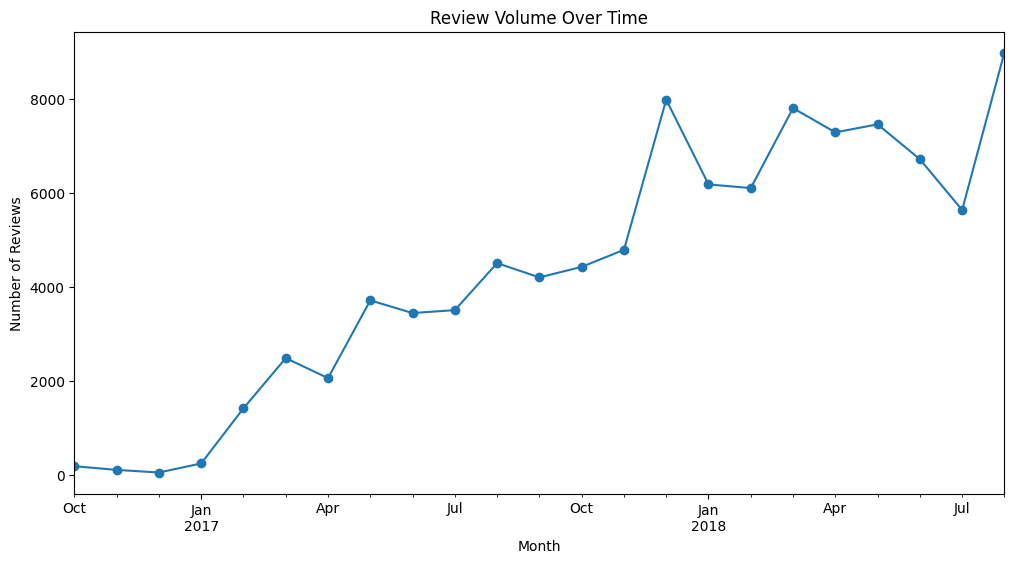

In [583]:
reviews['review_creation_date'] = pd.to_datetime(
    reviews['review_creation_date']
)

review_volume = (
    reviews
    .groupby(reviews['review_creation_date'].dt.to_period('M'))
    .size()
)

review_volume.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Review Volume Over Time')
plt.xlabel('Month')
plt.ylabel('Number of Reviews')

plt.show()

In [590]:
import csv

reviews.to_csv(
    '/content/drive/MyDrive/reviews_clean.csv',
    index=False,
    quoting=csv.QUOTE_ALL
)

In [591]:
orders.to_csv('/content/drive/MyDrive/orders_clean.csv', index=False)

customers.to_csv('/content/drive/MyDrive/customers_clean.csv', index=False)

products.to_csv('/content/drive/MyDrive/products_clean.csv', index=False)

order_items.to_csv('/content/drive/MyDrive/order_items_clean.csv', index=False)

payments.to_csv('/content/drive/MyDrive/payments_clean.csv', index=False)

reviews.to_csv('/content/drive/MyDrive/reviews_clean.csv', index=False)

In [592]:
import os

os.listdir('/content/drive/MyDrive/Brazilian_dataset')

['orders_clean.csv',
 'customers_clean.csv',
 'products_clean.csv',
 'order_items_clean.csv',
 'payments_clean.csv',
 'reviews_clean.csv']

In [593]:
reviews.to_parquet(
    '/content/drive/MyDrive/reviews_clean.parquet',
    index=False
)